In [21]:
import cv2, time, sys, os, pathlib, json
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def angle_between_points(p1, p2, p3):
    a = np.array(p1)
    b = np.array(p2)
    c = np.array(p3)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(cosine_angle)

    return np.degrees(angle)

In [23]:
try:
    with open('test.json', 'r') as file:
        data = json.load(file)
    print("File data =", data)
    
except FileNotFoundError:
    print("Error: The file 'test.json' was not found.")

File data = {'athlete': 'ATH01', 'session': 's1', 'video': 'Pre Cut03.2103582.20240108160826.avi', 'frame_count': 598, 'frames': [{'frame': 0, 'landmarks': []}, {'frame': 1, 'landmarks': [{'index': 11, 'name': 'LEFT_SHOULDER', 'x': 0.11706622689962387, 'y': -0.4616546630859375, 'z': 0.03729555010795593, 'visibility': 0.9994282126426697}, {'index': 12, 'name': 'RIGHT_SHOULDER', 'x': -0.1394786685705185, 'y': -0.44766372442245483, 'z': 0.1109730452299118, 'visibility': 0.9898667335510254}, {'index': 23, 'name': 'LEFT_HIP', 'x': 0.09292369335889816, 'y': 0.0009170409757643938, 'z': -0.010153437033295631, 'visibility': 0.9973864555358887}, {'index': 24, 'name': 'RIGHT_HIP', 'x': -0.09292730689048767, 'y': -0.0013195829233154655, 'z': 0.011377266608178616, 'visibility': 0.9880036115646362}, {'index': 25, 'name': 'LEFT_KNEE', 'x': 0.06862355023622513, 'y': 0.3851394057273865, 'z': -0.07585997879505157, 'visibility': 0.9287341833114624}, {'index': 26, 'name': 'RIGHT_KNEE', 'x': -0.06831783056

There is 17 frames with no landmarks in them. [{'frame': 0, 'landmarks': []}, {'frame': 2, 'landmarks': []}, {'frame': 9, 'landmarks': []}, {'frame': 21, 'landmarks': []}, {'frame': 22, 'landmarks': []}, {'frame': 31, 'landmarks': []}, {'frame': 34, 'landmarks': []}, {'frame': 35, 'landmarks': []}, {'frame': 38, 'landmarks': []}, {'frame': 43, 'landmarks': []}, {'frame': 46, 'landmarks': []}, {'frame': 49, 'landmarks': []}, {'frame': 50, 'landmarks': []}, {'frame': 51, 'landmarks': []}, {'frame': 52, 'landmarks': []}, {'frame': 54, 'landmarks': []}, {'frame': 55, 'landmarks': []}]


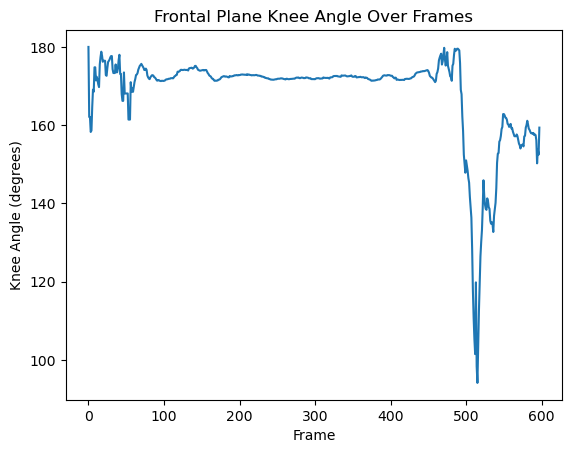

In [24]:
# Get a list with all the frames 
frames_list = list(data.items())[4][1]
angle_list = []
old_angle = 180
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame)
        p1, p2, p3 = None, None, None
        angle_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        left_knee = [a for a in frame['landmarks'] if a['name'] == 'LEFT_KNEE']
        left_ankle = [a for a in frame['landmarks'] if a['name'] == 'LEFT_ANKLE']
        p1 = [left_hip[0]['x'], left_hip[0]['y']]
        p2 = [left_knee[0]['x'], left_knee[0]['y']]
        p3 = [left_ankle[0]['x'], left_ankle[0]['y']]
        if left_hip is None or left_knee is None or left_ankle is None:
            print("Error: One of the points is None for frame", frame['frame'])
            break 
        angle = angle_between_points(p1, p2, p3)
        angle_list.append(angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
plt.plot(angle_list)
plt.xlabel('Frame')
plt.ylabel('Knee Angle (degrees)')
plt.title('Frontal Plane Knee Angle Over Frames')
plt.show()

In [25]:
def orientation_angle(left_hip, right_hip):
    angle = np.arccos((left_hip[0]['x'] - right_hip[0]['x']) / np.sqrt((left_hip[0]['x'] - right_hip[0]['x'])**2 + (left_hip[0]['z'] - right_hip[0]['z'])**2))
    return np.degrees(angle)

There is 17 frames with no landmarks in them. [0, 2, 9, 21, 22, 31, 34, 35, 38, 43, 46, 49, 50, 51, 52, 54, 55]


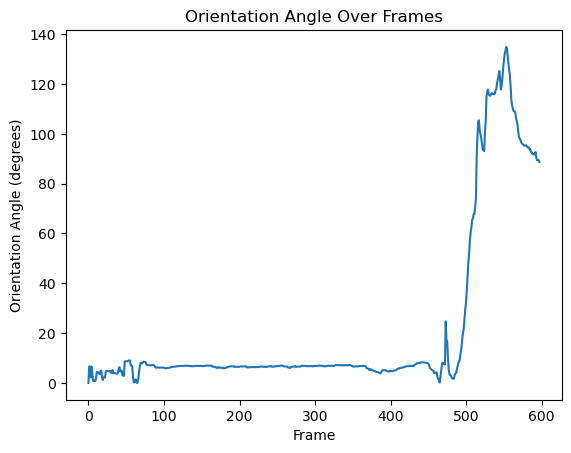

In [26]:
frames_list = list(data.items())[4][1]
orientation_list = []
old_angle = 0
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame['frame'])        
        p1, p2, p3 = None, None, None
        orientation_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        right_hip = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_HIP']
        if left_hip is None or right_hip is None:
            print("Error: No hip point found for frame", frame['frame'])
            break 
        angle = orientation_angle(left_hip, right_hip)
        orientation_list.append(angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
plt.plot(orientation_list)
plt.xlabel('Frame')
plt.ylabel('Orientation Angle (degrees)')
plt.title('Orientation Angle Over Frames')
plt.show()

In [27]:
unmarked_frames

[0, 2, 9, 21, 22, 31, 34, 35, 38, 43, 46, 49, 50, 51, 52, 54, 55]

# Computing the frontal plane from 3 landmarks (left hip, right hip, midpoint of hips and shoulders)

In [45]:
# This computes the normalized frontal plane normal vector using the hip and shoulder landmarks.
# It calculates the mid-point of the hips and shoulders, then creates two vectors from 
# the left hip to the mid-point and from the right hip to the mid-point.

def frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder):
    mid_point = [(left_hip[0]['x'] + right_hip[0]['x'] + left_shoulder[0]['x'] + right_shoulder[0]['x']) / 4, 
                 (left_hip[0]['y'] + right_hip[0]['y'] + left_shoulder[0]['y'] + right_shoulder[0]['y']) / 4, 
                 (left_hip[0]['z'] + right_hip[0]['z'] + left_shoulder[0]['z'] + right_shoulder[0]['z']) / 4]
    v1 = [left_hip[0]['x'] - mid_point[0], left_hip[0]['y'] - mid_point[1], left_hip[0]['z'] - mid_point[2]]
    v2 = [right_hip[0]['x'] - mid_point[0], right_hip[0]['y'] - mid_point[1], right_hip[0]['z'] - mid_point[2]]
    normal_vector = np.cross(v1, v2)
    return normal_vector / np.linalg.norm(normal_vector)

In [46]:
def normal_vector_angle(normal_vector):
    angle = np.arccos(normal_vector[2])  # Assuming the normal vector is normalized
    return np.degrees(angle)

There is 17 frames with no landmarks in them. [{'frame': 0, 'landmarks': []}, {'frame': 2, 'landmarks': []}, {'frame': 9, 'landmarks': []}, {'frame': 21, 'landmarks': []}, {'frame': 22, 'landmarks': []}, {'frame': 31, 'landmarks': []}, {'frame': 34, 'landmarks': []}, {'frame': 35, 'landmarks': []}, {'frame': 38, 'landmarks': []}, {'frame': 43, 'landmarks': []}, {'frame': 46, 'landmarks': []}, {'frame': 49, 'landmarks': []}, {'frame': 50, 'landmarks': []}, {'frame': 51, 'landmarks': []}, {'frame': 52, 'landmarks': []}, {'frame': 54, 'landmarks': []}, {'frame': 55, 'landmarks': []}]


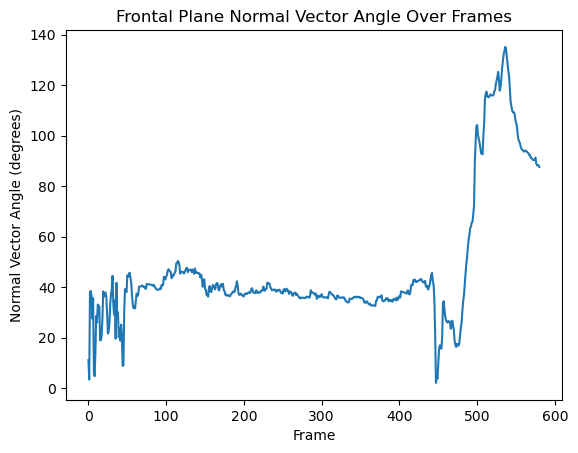

In [47]:
# Get a list with all the frames 
frames_list = list(data.items())[4][1]
normal_vector_angle_list = []
old_angle = 180
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame)
        p1, p2, p3 = None, None, None
        angle_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        left_shoulder = [a for a in frame['landmarks'] if a['name'] == 'LEFT_SHOULDER']
        right_hip = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_HIP']
        right_shoulder = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_SHOULDER']
        normal_vector = frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder)
        angle = normal_vector_angle(normal_vector)
        normal_vector_angle_list.append(angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
plt.plot(normal_vector_angle_list)
plt.xlabel('Frame')
plt.ylabel('Normal Vector Angle (degrees)')
plt.title('Frontal Plane Normal Vector Angle Over Frames')
plt.show()

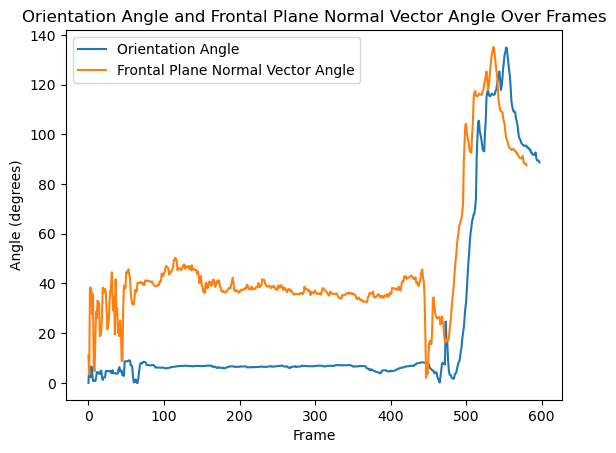

In [48]:
# Plot side to side the orientation angle and the frontal plane normal vector angle
plt.plot(orientation_list, label='Orientation Angle')
plt.plot(normal_vector_angle_list, label='Frontal Plane Normal Vector Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Orientation Angle and Frontal Plane Normal Vector Angle Over Frames')
plt.legend()
plt.show()

# Projecting Femur and Tibia onto the normal plane

In [49]:
def projection_onto_the_frontal_plane(v1, v2, n):
    v1_proj = n - np.dot(v1, n) * v1
    v2_proj = n - np.dot(v2, n) * v2
    return v1_proj, v2_proj

In [50]:
def angle_between_vectors(v1, v2):
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle = np.arccos(cosine_angle)
    if np.cross(v1, v2)[2] > 0:  # Check the sign of the angle using the cross product
        angle = -angle
    return np.degrees(angle)

There is 17 frames with no landmarks in them. [{'frame': 0, 'landmarks': []}, {'frame': 2, 'landmarks': []}, {'frame': 9, 'landmarks': []}, {'frame': 21, 'landmarks': []}, {'frame': 22, 'landmarks': []}, {'frame': 31, 'landmarks': []}, {'frame': 34, 'landmarks': []}, {'frame': 35, 'landmarks': []}, {'frame': 38, 'landmarks': []}, {'frame': 43, 'landmarks': []}, {'frame': 46, 'landmarks': []}, {'frame': 49, 'landmarks': []}, {'frame': 50, 'landmarks': []}, {'frame': 51, 'landmarks': []}, {'frame': 52, 'landmarks': []}, {'frame': 54, 'landmarks': []}, {'frame': 55, 'landmarks': []}]


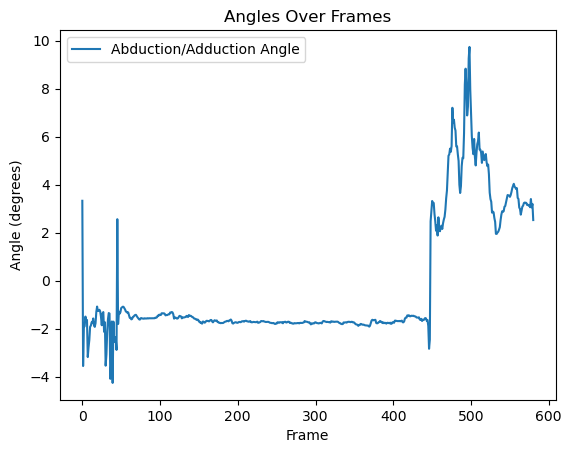

In [57]:
# Get a list with all the frames 
frames_list = list(data.items())[4][1]
normal_vector_angle_list = []
abduction_adduction_angle_list = []
old_angle = 180
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame)
        p1, p2, p3 = None, None, None
        angle_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        left_shoulder = [a for a in frame['landmarks'] if a['name'] == 'LEFT_SHOULDER']
        right_hip = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_HIP']
        right_shoulder = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_SHOULDER']
        left_knee = [a for a in frame['landmarks'] if a['name'] == 'LEFT_KNEE']
        left_ankle = [a for a in frame['landmarks'] if a['name'] == 'LEFT_ANKLE']
        normal_vector = frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder)
        angle = normal_vector_angle(normal_vector)
        femur = np.array([left_knee[0]['x'] - left_hip[0]['x'], left_knee[0]['y'] - left_hip[0]['y'], left_knee[0]['z'] - left_hip[0]['z']])
        tibia = np.array([left_ankle[0]['x'] - left_knee[0]['x'], left_ankle[0]['y'] - left_knee[0]['y'], left_ankle[0]['z'] - left_knee[0]['z']])
        femur_proj, tibia_proj = projection_onto_the_frontal_plane(femur, tibia, normal_vector)
        abduction_adduction_angle = angle_between_vectors(femur_proj, tibia_proj)
        normal_vector_angle_list.append(angle)
        abduction_adduction_angle_list.append(abduction_adduction_angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
# plt.plot(normal_vector_angle_list, label='Frontal Plane Normal Vector Angle')
plt.plot(abduction_adduction_angle_list, label='Abduction/Adduction Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Angles Over Frames')
plt.legend()
plt.show()

In [35]:
np.atan2(tibia, femur)

array([1.83113317, 0.75079887, 2.19572414])

# -----------------------------------------------------------------------

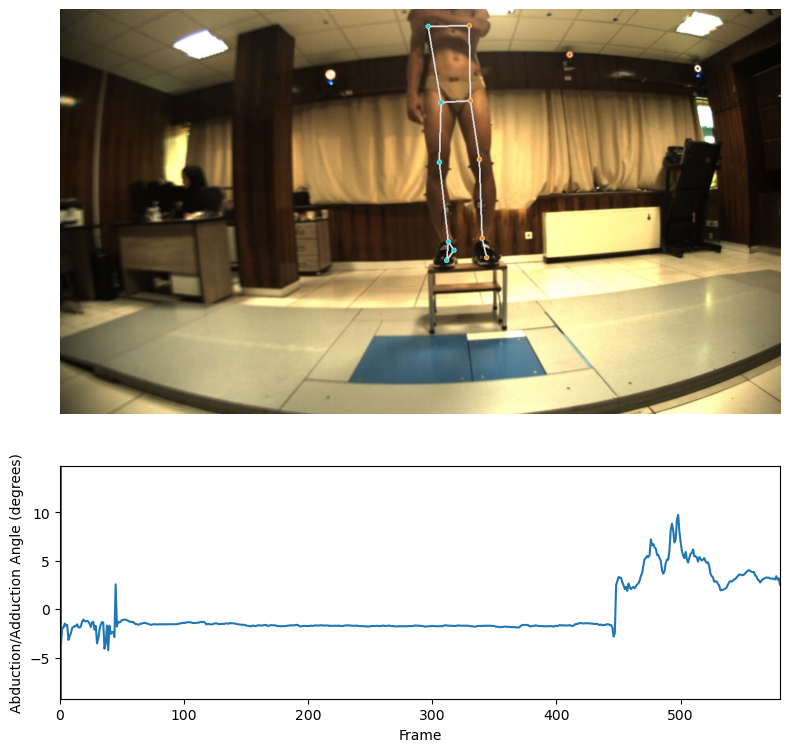

In [63]:
# Synchronized video (top) + knee-angle plot (bottom) animation
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


video_path = 'test_annoted.avi'
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 30
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)
cap.release()

# Ensure `angle_list` exists (computed earlier) and synchronize lengths
try:
    n_frames = min(len(frames), len(abduction_adduction_angle_list))
except NameError:
    raise NameError('abduction_adduction_angle_list not found. Run the cell that computes abduction and adduction angles first.')
if n_frames == 0:
    raise RuntimeError('No frames or abduction/adduction angles available to animate.')
frames = frames[:n_frames]
angles = np.array(abduction_adduction_angle_list[:n_frames])
# vectors = np.array(orientation_list[:n_frames])

# Create figure with video on top and plot below
fig = plt.figure(figsize=(8,8))
ax_vid = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax_plot = plt.subplot2grid((3,1),(2,0))
im = ax_vid.imshow(frames[0])
ax_vid.axis('off')
# Plot full angle trace and set up vertical frame indicator
ax_plot.plot(np.arange(n_frames), angles, color='C0')
# ax_plot.plot(np.arange(n_frames), vectors, color='C1')
vline = ax_plot.axvline(0, color='r', linewidth=2)
ax_plot.set_xlim(0, n_frames-1)
pad = max(5, (angles.max()-angles.min())*0.05)
ax_plot.set_ylim(angles.min()-pad, angles.max()+pad)
ax_plot.set_xlabel('Frame')
ax_plot.set_ylabel('Abduction/Adduction Angle (degrees)')
plt.tight_layout()

# Init function: display first frame and set vertical line to 0
# def init():
#     im.set_data(frames[0])
#     vline.set_xdata(0)
#     return im, vline

# Update function: swap video frame and move vertical line
def update(i, frames, im, vline):
    im.set_data(frames[i])
    vline.set_xdata([i,i])
    return im, vline

interval = 1000.0 / (fps if fps>0 else 30)
ani = animation.FuncAnimation(fig, update, frames=n_frames, fargs=(frames, im, vline), blit=False, interval=interval)
# Display as JS animation inline in the notebook
ani.save('abduction_adduction.mp4', writer='ffmpeg')

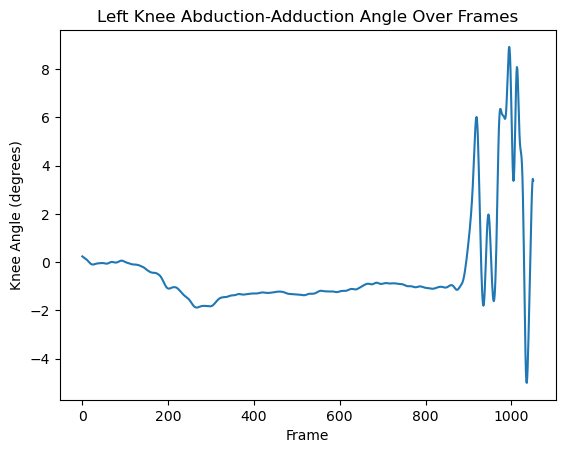

In [42]:
# from the ATH01_S1_PreCut03.csv file, get the left knee abduction-adduction angle over frames and plot it.

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('ATH01_S1_PreCUT03.csv')
angles = df['LKNE_Abduction_Adduction']

plt.plot(angles)
plt.xlabel('Frame')
plt.ylabel('Knee Angle (degrees)')
plt.title('Left Knee Abduction-Adduction Angle Over Frames')
plt.show()

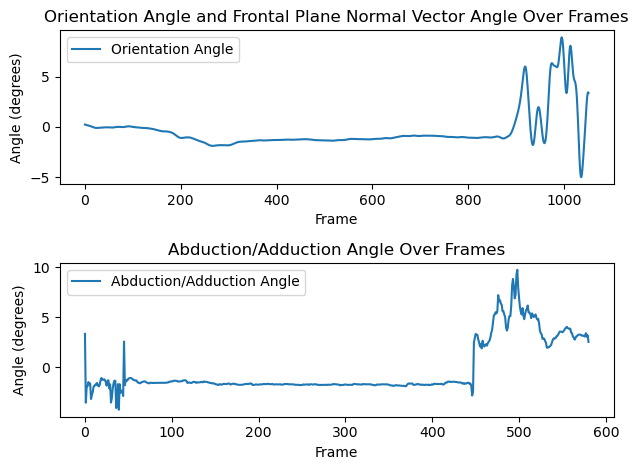

<Figure size 640x480 with 0 Axes>

In [44]:
# PLot next to each other the abduction-adduction angle and the angles from the csv file over frames.
plt.subplot(2, 1, 1)
plt.plot(df['LKNE_Abduction_Adduction'], label='Orientation Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Orientation Angle and Frontal Plane Normal Vector Angle Over Frames')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(abduction_adduction_angle_list, label='Abduction/Adduction Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Abduction/Adduction Angle Over Frames')
plt.legend()
plt.tight_layout()
plt.show()
# Save the plot as a png file
plt.savefig('angles_comparison.png')

In [62]:
print(f"Max abduction/adduction angle: {max(abduction_adduction_angle_list)}")
print(f"Max ground truth angle: {max(df['LKNE_Abduction_Adduction'])}")
print(f"Min abduction/adduction angle: {min(abduction_adduction_angle_list)}")
print(f"Min ground truth angle: {min(df['LKNE_Abduction_Adduction'])}")

Max abduction/adduction angle: 9.738444934217533
Max ground truth angle: 8.916638311568255
Min abduction/adduction angle: -4.25743217118383
Min ground truth angle: -5.003753187179302
